<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/tversky_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (87554, 188)
Test shape: (21892, 188)


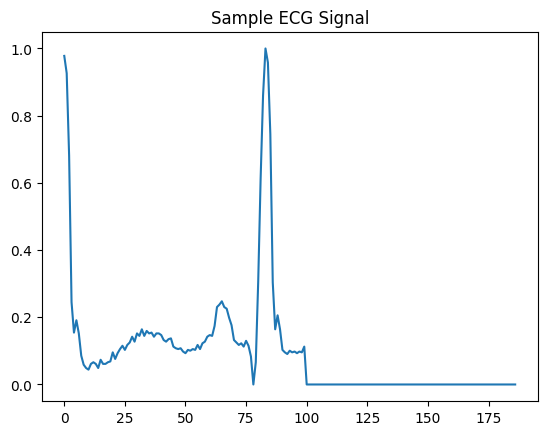

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

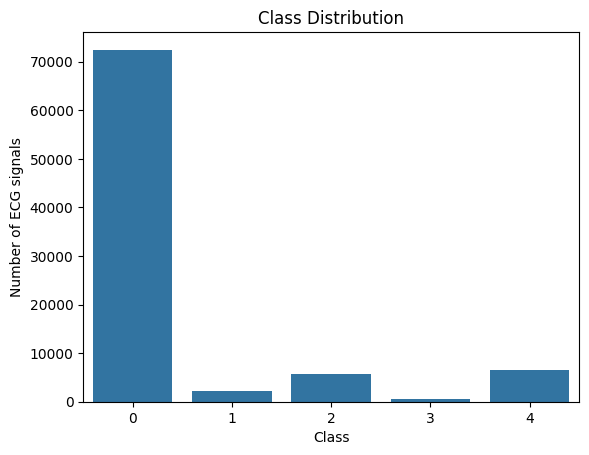

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [7]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def tversky_loss(y_true, y_pred):

    alpha = 0.7
    beta = 0.3
    smooth = 1e-7

    y_true = tf.cast(y_true, tf.float32)

    TP = tf.reduce_sum(y_true * y_pred, axis=1)
    FP = tf.reduce_sum((1 - y_true) * y_pred, axis=1)
    FN = tf.reduce_sum(y_true * (1 - y_pred), axis=1)

    tversky = (TP + smooth) / (TP + alpha*FP + beta*FN + smooth)

    return 1 - tf.reduce_mean(tversky)

In [13]:
def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=tversky_loss,
        metrics=['accuracy']
    )

    return model

In [14]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 319s 83ms/step - accuracy: 0.9065 - loss: 0.0977
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 312s 80ms/step - accuracy: 0.9528 - loss: 0.0489
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 301s 80ms/step - accuracy: 0.9630 - loss: 0.0381
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 304s 80ms/step - accuracy: 0.9697 - loss: 0.0313
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 303s 80ms/step - accuracy: 0.9737 - loss: 0.0270

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 318s 83ms/step - accuracy: 0.9044 - loss: 0.1003
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 311s 82ms/step - accuracy: 0.9509 - loss: 0.0510
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 313s 83ms/step - accuracy: 0.9598 - loss: 0.0413
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 307s 81ms/step - accuracy: 0.9662 - loss: 0.0348
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 307s 81ms/step - accuracy: 0.9705 - loss: 0.0303

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 309s 80ms/step - accuracy: 0.9046 -

In [15]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [16]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 393s 86ms/step - accuracy: 0.9029 - loss: 0.1011 - val_accuracy: 0.9121 - val_loss: 0.0905
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 386s 85ms/step - accuracy: 0.9519 - loss: 0.0495 - val_accuracy: 0.9079 - val_loss: 0.0934
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 383s 85ms/step - accuracy: 0.9615 - loss: 0.0396 - val_accuracy: 0.9488 - val_loss: 0.0522
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 383s 85ms/step - accuracy: 0.9695 - loss: 0.0314 - val_accuracy: 0.9067 - val_loss: 0.0954
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 386s 85ms/step - accuracy: 0.9735 - loss: 0.0273 - val_accuracy: 0.9659 - val_loss: 0.0349
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 454s 88ms/step - accuracy: 0.9768 - loss: 0.0239 - val_accuracy: 0.9570 - val_loss: 0.0442
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 397s 88ms/step - accuracy: 0.9790 - loss: 0.0215 - val_accuracy: 0.9275 - val_loss: 0.0736
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 426s 84ms/step - accuracy: 

Final Training Accuracy: 0.98273104429245
Final Validation Accuracy: 0.935767412185669


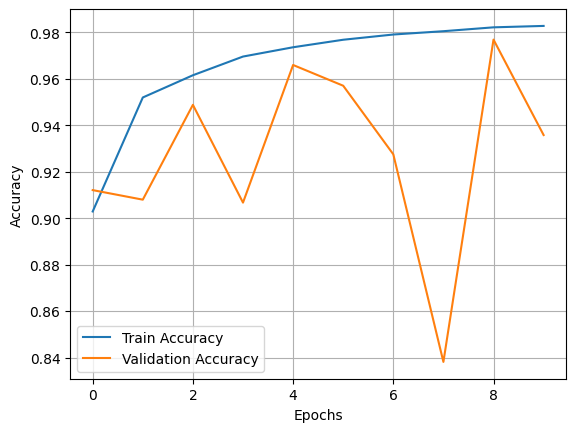

In [17]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

Final Training Loss: 0.01765812560915947
Final Validation Loss: 0.06498333066701889


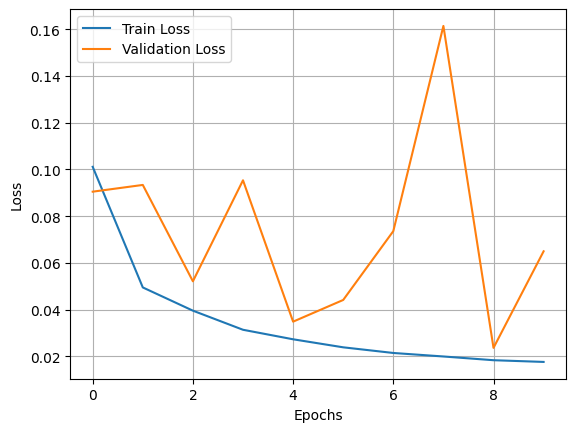

In [18]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: 0.09500768035650253
Test Accuracy: 0.905718982219696
685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.94     18118
         1.0       0.29      0.79      0.43       556
         2.0       0.68      0.97      0.80      1448
         3.0       0.51      0.67      0.58       162
         4.0       0.94      0.96      0.95      1608

    accuracy                           0.91     21892
   macro avg       0.68      0.86      0.74     21892
weighted avg       0.95      0.91      0.92     21892



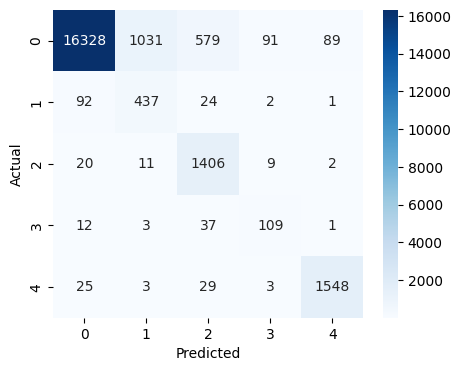

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()